--- Instantiating Declarative Survival API ---
--- Fitting Model (Abstracted PyTensor Graph) ---

--- Model Summary ---
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha       1.176  0.062   1.065    1.293      0.002    0.001    1373.0   
intercept   2.092  0.074   1.963    2.235      0.002    0.002    1141.0   
weights[0]  0.670  0.112   0.457    0.874      0.003    0.003    1160.0   

            ess_tail  r_hat  
alpha         1436.0    1.0  
intercept     1248.0    1.0  
weights[0]    1105.0    1.0  

--- Generating Diagnostic Plot ---


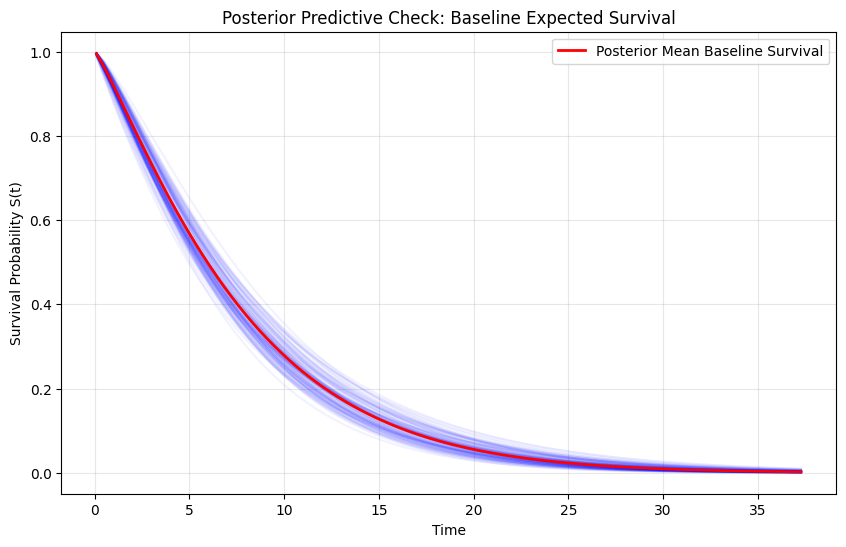

In [1]:
import pymc as pm
import pytensor.tensor as pt
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

class BayesianSurvivalModel:
    """
    A Declarative API for Advanced Bayesian Survival Analysis in PyMC.
    Handles right-censoring, covariates (AFT formulation), and visual diagnostics.
    """
    def __init__(self, df: pd.DataFrame, time_col: str, event_col: str, covariates: list):
        self.df = df
        self.time = df[time_col].values
        self.event = df[event_col].values
        # In the final version, this will use 'patsy' or 'formulaic' for formula parsing
        self.X = df[covariates].values 
        self.covariates = covariates
        self.model = None
        self.idata = None

    def _weibull_aft_logp(self, time, event, alpha, lambda_):
        """
        PyTensor log-likelihood for right-censored Weibull Accelerated Failure Time (AFT) model.
        lambda_ is the dynamically computed scale parameter based on covariates.
        """
        # Log Probability Density Function (Uncensored / Event occurred)
        log_pdf = pt.log(alpha) - pt.log(lambda_) + (alpha - 1) * pt.log(time / lambda_) - (time / lambda_)**alpha
        
        # Log Survival Function (Right-Censored)
        log_sf = -(time / lambda_)**alpha
        
        # Branching logic: apply PDF if event==1, else apply SF
        return pt.sum(pt.where(event, log_pdf, log_sf))

    def fit(self, draws=1000, tune=1000):
        """Builds the PyMC computational graph and samples the posterior."""
        with pm.Model() as self.model:
            # 1. Base Priors
            alpha = pm.HalfNormal("alpha", sigma=5)
            intercept = pm.Normal("intercept", mu=0, sigma=5)
            
            # 2. Covariate Weights (The "AFT" component)
            weights = pm.Normal("weights", mu=0, sigma=2, shape=self.X.shape[1])
            
            # 3. Link Function: Compute Scale (lambda) from covariates
            mu = intercept + pm.math.dot(self.X, weights)
            lambda_ = pm.math.exp(mu)

            # 4. Custom Distribution handling the censoring math
            pm.CustomDist(
                "obs", 
                self.event, 
                alpha, 
                lambda_, 
                logp=self._weibull_aft_logp, 
                observed=self.time
            )
            
            # Sample
            self.idata = pm.sample(draws=draws, tune=tune, target_accept=0.9, return_inferencedata=True, progressbar=False)
        
        return self.idata

    def plot_expected_survival(self):
        """
        Demonstrates the 'Diagnostics Suite' Phase of the GSoC proposal.
        Plots the expected baseline survival curve from the posterior.
        """
        if self.idata is None:
            raise ValueError("Model must be fitted before plotting diagnostics.")
            
        post = self.idata.posterior
        alpha_samples = post["alpha"].values.flatten()
        intercept_samples = post["intercept"].values.flatten()
        
        # Baseline lambda (assuming covariates = 0)
        lambda_samples = np.exp(intercept_samples)
        
        t = np.linspace(0.1, self.time.max(), 100)
        
        # Calculate survival probability S(t) = exp(-(t/lambda)^alpha) for a random subset of posterior draws
        plt.figure(figsize=(10, 6))
        idx = np.random.choice(len(alpha_samples), 100, replace=False)
        
        for i in idx:
            S_t = np.exp(-(t / lambda_samples[i])**alpha_samples[i])
            plt.plot(t, S_t, color='blue', alpha=0.05)
            
        # Plot posterior mean
        mean_alpha = alpha_samples.mean()
        mean_lambda = lambda_samples.mean()
        mean_S_t = np.exp(-(t / mean_lambda)**mean_alpha)
        plt.plot(t, mean_S_t, color='red', linewidth=2, label='Posterior Mean Baseline Survival')
        
        plt.title("Posterior Predictive Check: Baseline Expected Survival")
        plt.xlabel("Time")
        plt.ylabel("Survival Probability S(t)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()



if __name__ == "__main__":
    # 1. Generate Dummy Data (Treatment vs Control Group)
    np.random.seed(42)
    n = 300
    treatment = np.random.binomial(1, 0.5, n) # 0 or 1
    
    # Treatment increases survival time (increases lambda)
    true_alpha = 1.2
    true_intercept = 2.0
    true_weight = 0.8
    
    true_lambda = np.exp(true_intercept + treatment * true_weight)
    true_times = np.random.weibull(true_alpha, n) * true_lambda
    
    # Apply random right-censoring
    censoring_times = np.random.uniform(5, 40, n)
    observed_times = np.minimum(true_times, censoring_times)
    events = (true_times <= censoring_times).astype(int)
    
    df = pd.DataFrame({
        'time': observed_times, 
        'event': events, 
        'treatment_group': treatment
    })

    print("--- Instantiating Declarative Survival API ---")
    surv_model = BayesianSurvivalModel(
        df=df, 
        time_col='time', 
        event_col='event', 
        covariates=['treatment_group']
    )
    
    print("--- Fitting Model (Abstracted PyTensor Graph) ---")
    surv_model.fit(draws=1000, tune=1000)
    
    print("\n--- Model Summary ---")
    print(az.summary(surv_model.idata, var_names=["alpha", "intercept", "weights"]))
    
    print("\n--- Generating Diagnostic Plot ---")
    surv_model.plot_expected_survival()